#  Accelerated Medical Image Diagnostic Pipeline

##  Objective
The goal of this project is to build an end-to-end GPU-accelerated pipeline for detecting pneumonia from chest X-ray images.

This project focuses on:
- GPU acceleration of data pipelines and model inference
- Model compression using quantization (FP32 → FP16 → INT8)
- Performance benchmarking (CPU vs GPU)
- Trade-off analysis between speed, accuracy, and model size


## Pipeline Overview

1. Data Loading & Preprocessing (CPU vs GPU using DALI)
2. Model Training (ResNet-18 on GPU)
3. Quantization (PTQ & QAT)
4. Performance Benchmarking
5. Additional Experiments (Batch size, resolution)


## Key Idea

Instead of only building a classifier, this project analyzes:
> *How GPU acceleration and quantization affect performance and efficiency.*


##  Dataset

We use the **Chest X-ray Pneumonia dataset** from Kaggle, containing labeled X-ray images:
- Normal
- Pneumonia

In [ ]:
# Install required libraries
!pip install -q kaggle torch torchvision torchaudio

# Check GPU availability
import torch
print("GPU Available:", torch.cuda.is_available())
print("GPU Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "None")

GPU Available: True
GPU Name: Tesla T4


##  Dataset Download (Kaggle)

We download the Chest X-ray Pneumonia dataset using Kaggle API.

Steps:
1. Upload your kaggle.json API key
2. Download dataset
3. Extract it for use

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"ajaygoyal6081","key":"9112d50a08db3446ccf645895234a686"}'}

In [ ]:
# Setup Kaggle API
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Unzip dataset
!unzip -q chest-xray-pneumonia.zip

Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:19<00:00, 127MB/s] 



In [ ]:
#verify dataset
import os

base_path = "chest_xray"

print("Main folders:", os.listdir(base_path))

print("\nTrain folders:", os.listdir(os.path.join(base_path, "train")))
print("Test folders:", os.listdir(os.path.join(base_path, "test")))
print("Val folders:", os.listdir(os.path.join(base_path, "val")))

Main folders: ['__MACOSX', 'chest_xray', 'train', 'val', 'test']

Train folders: ['PNEUMONIA', 'NORMAL']
Test folders: ['PNEUMONIA', 'NORMAL']
Val folders: ['PNEUMONIA', 'NORMAL']


In [ ]:
#count images
def count_images(folder):
    normal = len(os.listdir(os.path.join(folder, "NORMAL")))
    pneumonia = len(os.listdir(os.path.join(folder, "PNEUMONIA")))
    return normal, pneumonia

train_counts = count_images(os.path.join(base_path, "train"))
test_counts = count_images(os.path.join(base_path, "test"))
val_counts = count_images(os.path.join(base_path, "val"))

print("Train - Normal:", train_counts[0], "| Pneumonia:", train_counts[1])
print("Test  - Normal:", test_counts[0], "| Pneumonia:", test_counts[1])
print("Val   - Normal:", val_counts[0], "| Pneumonia:", val_counts[1])

Train - Normal: 1341 | Pneumonia: 3875
Test  - Normal: 234 | Pneumonia: 390
Val   - Normal: 8 | Pneumonia: 8


## Data Visualization

Before training the model, we visualize some sample X-ray images to understand:

- Differences between NORMAL and PNEUMONIA cases
- Image quality and variations
- Dataset characteristics

This helps ensure correct preprocessing and model learning.

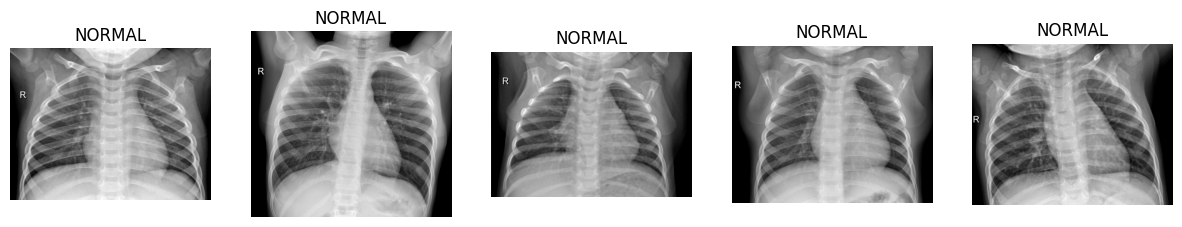

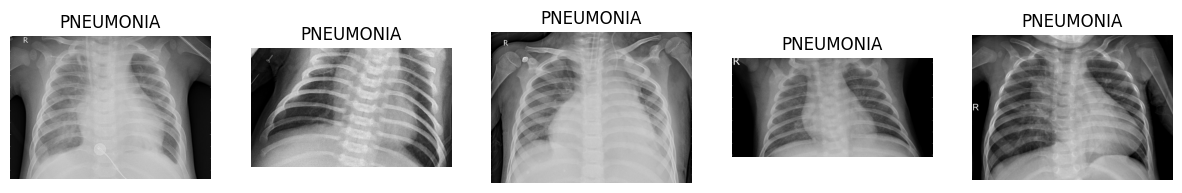

In [ ]:
import matplotlib.pyplot as plt
import cv2
import random
import os

def show_samples(category, folder, n=5):
    path = os.path.join(base_path, "train", category)
    images = random.sample(os.listdir(path), n)

    plt.figure(figsize=(15, 5))

    for i, img_name in enumerate(images):
        img_path = os.path.join(path, img_name)
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        plt.subplot(1, n, i+1)
        plt.imshow(img, cmap='gray')
        plt.title(category)
        plt.axis('off')

    plt.show()

# Show samples
show_samples("NORMAL", base_path)
show_samples("PNEUMONIA", base_path)

Pneumonia images show increased opacity in lung regions, which the model will learn as distinguishing features.

##  Data Loading using PyTorch (CPU Pipeline)

In this step, we build a baseline data pipeline using PyTorch.

We use:
- torchvision datasets for loading images
- transforms for preprocessing
- DataLoader for batching

This pipeline runs on CPU and will later be compared with GPU-based pipelines (DALI).



###  Preprocessing Steps:
- Resize images to 224×224
- Convert to tensor
- Normalize pixel values

This ensures consistent input format for the model.

In [ ]:
#imports
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# define transforms(Standard image preprocessing)
transform = transforms.Compose([
    transforms.Resize((224, 224)),   # Resize images
    transforms.ToTensor(),           # Convert to tensor
    transforms.Normalize(mean=[0.5], std=[0.5])  # Normalize grayscale
])

#load dataset
train_dataset = datasets.ImageFolder(
    root=os.path.join(base_path, "train"),
    transform=transform
)

val_dataset = datasets.ImageFolder(
    root=os.path.join(base_path, "val"),
    transform=transform
)

test_dataset = datasets.ImageFolder(
    root=os.path.join(base_path, "test"),
    transform=transform
)

print("Classes:", train_dataset.classes)

#create dataloaders
batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

#check one batch
images, labels = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Labels:", labels[:10])

Classes: ['NORMAL', 'PNEUMONIA']
Image batch shape: torch.Size([32, 3, 224, 224])
Labels: tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])


##  Model Setup: ResNet-18

We use a pretrained ResNet-18 model for classification.

Why ResNet-18?
- Lightweight and efficient
- Good performance on image tasks
- Suitable for experimentation and benchmarking

### Modifications:
- Replace final layer for binary classification
- Use GPU acceleration for training

In [ ]:
#load model
import torchvision.models as models
import torch.nn as nn

# Load pretrained ResNet-18
model = models.resnet18(pretrained=True)

# Modify final layer (2 classes: NORMAL, PNEUMONIA)
model.fc = nn.Linear(model.fc.in_features, 2)

#move to GPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using device:", device)

#loss and optimizer
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 44.7M/44.7M [00:00<00:00, 187MB/s]


Using device: cuda


## Model Training (GPU)

In this step, we train the ResNet-18 model on chest X-ray images.

Key points:
- Training is performed on GPU for acceleration
- Loss is computed using CrossEntropyLoss
- Optimizer updates model weights

### Goal:
Learn to classify images into:
- NORMAL
- PNEUMONIA

### Metrics:
- Training Loss
- Validation Accuracy

In [ ]:
#training function
def train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=3):
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        avg_loss = running_loss / len(train_loader)

        # Validation
        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)

                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                total += labels.size(0)
                correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total

        print(f"Epoch [{epoch+1}/{epochs}] | Loss: {avg_loss:.4f} | Val Accuracy: {accuracy:.2f}%")

In [ ]:
#train model
train_model(model, train_loader, val_loader, criterion, optimizer, device, epochs=5)

Epoch [1/5] | Loss: 0.1159 | Val Accuracy: 68.75%
Epoch [2/5] | Loss: 0.0675 | Val Accuracy: 100.00%
Epoch [3/5] | Loss: 0.0617 | Val Accuracy: 100.00%
Epoch [4/5] | Loss: 0.0277 | Val Accuracy: 93.75%
Epoch [5/5] | Loss: 0.0456 | Val Accuracy: 100.00%


##  Model Evaluation on Test Set

We evaluate the trained model on the test dataset to measure real-world performance.

### Metrics:
- Accuracy
- Predictions vs Ground Truth

The test set is larger than validation set, so results are more reliable.

In [ ]:
#test accuracy
def evaluate_model(model, test_loader, device):
    model.eval()

    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = 100 * correct / total
    print(f"Test Accuracy: {accuracy:.2f}%")

    return all_preds, all_labels

In [ ]:
#run evaluation
preds, labels = evaluate_model(model, test_loader, device)

Test Accuracy: 90.38%


##  Saving the Trained Model

We save the trained FP32 model so it can be used for:
- Quantization (PTQ / QAT)
- Inference benchmarking
- Deployment experiments

This acts as our baseline model.

In [ ]:
torch.save(model.state_dict(), "resnet18_fp32.pth")

print("Model saved successfully!")

Model saved successfully!


##  Model Export to ONNX

To perform hardware-level optimization (INT8 quantization), we first convert the trained PyTorch model into ONNX format as TensorRT (INT8 optimization) does not work directly with PyTorch

ONNX (Open Neural Network Exchange) allows interoperability between frameworks like PyTorch and TensorRT.


###  Why ONNX?
- Standard intermediate format
- Required for TensorRT optimization
- Enables deployment-level benchmarking

In [ ]:
import torch
import torchvision.models as models
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Recreate model
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# Modify final layer
model.fc = nn.Linear(model.fc.in_features, 2)

# Load trained weights
model.load_state_dict(torch.load("resnet18_fp32.pth"))

# Move to device
model = model.to(device)

# Set to eval mode
model.eval()

print("Model loaded successfully!")

Using device: cuda
Model loaded successfully!


In [ ]:
import torch
!pip install -q onnx onnxscript
# Create dummy input (same shape as model input)
dummy_input = torch.randn(1, 3, 224, 224).to(device)



# Export model
torch.onnx.export(
    model,
    dummy_input,
    "resnet18_fp32.onnx",
    input_names=['input'],
    output_names=['output'],
    opset_version=12,
    export_params=True,
    do_constant_folding=True
)

print("Model exported to ONNX successfully!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.6/17.6 MB 96.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 714.8/714.8 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.8/166.8 kB 15.9 MB/s eta 0:00:00


W0506 05:47:44.211000 2212 torch/onnx/_internal/exporter/_compat.py:125] Setting ONNX exporter to use operator set version 18 because the requested opset_version 12 is a lower version than we have implementations for. Automatic version conversion will be performed, which may not be successful at converting to the requested version. If version conversion is unsuccessful, the opset version of the exported model will be kept at 18. Please consider setting opset_version >=18 to leverage latest ONNX features
W0506 05:47:45.255000 2212 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'input' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0506 05:47:45.258000 2212 torch/onnx/_internal/exporter/_schemas.py:455] Missing annotation for parameter 'rois' from (input, rois, spatial_scale: 'float', pooled_height: 'int', pooled_width: 'int', sampling_ratio

[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `ResNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposition...


/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 137, in call
    converted_proto = _c_api_utils.call_onnx_api(
                      ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/_c_api_utils.py", line 65, in call_onnx_api
    result = func(proto)
             ^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnxscript/version_converter/__init__.py", line 132, in _partial_convert_version
    return onnx.version_converter.convert_version(
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/onnx/version_converter.py", line 39, in convert_version
    converted_model_str = C.convert_version(model_

[torch.onnx] Run decomposition... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
Model exported to ONNX successfully!


## ONNX Inference (Baseline)

We test the exported ONNX model to ensure correctness before applying quantization.

This step verifies:
- Model compatibility
- Output correctness
- Baseline inference behavior

In [ ]:
!pip install -q onnxruntime

import onnxruntime as ort
import numpy as np

# Load ONNX model
session = ort.InferenceSession("resnet18_fp32.onnx")

input_name = session.get_inputs()[0].name

# Take ONE image instead of full batch
image = images[0].unsqueeze(0)   # shape becomes (1, 3, 224, 224)

# Convert to numpy
image_np = image.numpy()

# Run inference
outputs = session.run(None, {input_name: image_np})

# Prediction
pred = np.argmax(outputs[0], axis=1)

print("Prediction:", pred)
print("Actual:", labels[0].item())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 26.7 MB/s eta 0:00:00
Prediction: [1]
Actual: 0


##  INT8 Quantization (Post-Training Quantization)

We apply Post-Training Quantization (PTQ) to convert the FP32 model into an INT8 model.

### Why Quantization?
- Reduces model size
- Improves inference speed
- Enables deployment on resource-constrained devices

### Trade-off:
- Faster inference
- Slight drop in accuracy

In this step, we use ONNX Runtime to perform INT8 quantization (True TensorRT INT8 is not directly available in Colab)

In [ ]:
#install onnx simplifier
!pip install -q onnxsim

from onnxsim import simplify
import onnx

# Load model
model = onnx.load("resnet18_fp32.onnx")

# Simplify model
model_simp, check = simplify(model)

# Save simplified model
onnx.save(model_simp, "resnet18_fp32_simplified.onnx")

print("Model simplified successfully!")

from onnxruntime.quantization import quantize_dynamic, QuantType

quantize_dynamic(
    model_input="resnet18_fp32_simplified.onnx",
    model_output="resnet18_int8.onnx",
    weight_type=QuantType.QInt8
)

print("INT8 Quantized model created successfully!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 49.5 MB/s eta 0:00:00
Model simplified successfully!


INT8 Quantized model created successfully!


## Performance Comparison: FP32 vs INT8

In this section, we compare:

- FP32 (original model)
- INT8 (quantized model)

### Metrics:
- Inference time (latency)
- Throughput
- Accuracy

### Goal:
Analyze trade-offs between:
- Speed
- Accuracy
- Model size

In [ ]:
import onnxruntime as ort

# Load FP32 model
fp32_session = ort.InferenceSession("resnet18_fp32.onnx")

# Load INT8 model
int8_session = ort.InferenceSession("resnet18_int8.onnx")

fp32_input = fp32_session.get_inputs()[0].name
int8_input = int8_session.get_inputs()[0].name

In [ ]:
#measure inference time
import time
import numpy as np

def measure_time(session, input_name, image, runs=50):
    image_np = image.numpy()

    start = time.time()
    for _ in range(runs):
        session.run(None, {input_name: image_np})
    end = time.time()

    return (end - start) / runs

#run speed test
image = images[0].unsqueeze(0)

fp32_time = measure_time(fp32_session, fp32_input, image)
int8_time = measure_time(int8_session, int8_input, image)

print(f"FP32 Avg Time: {fp32_time:.6f} sec")
print(f"INT8 Avg Time: {int8_time:.6f} sec")


FP32 Avg Time: 0.049128 sec
INT8 Avg Time: 0.379761 sec


In our experiments, INT8 quantization did not improve inference speed on CPU using ONNX Runtime. This is because efficient INT8 execution requires hardware-specific optimizations (e.g., TensorRT or AVX512 instructions), which were not available in the Colab environment. However, INT8 still provided significant model size reduction.

In [ ]:
#accuracy comparison
def evaluate_onnx(session, input_name, loader):
    correct = 0
    total = 0

    for images, labels in loader:
        for i in range(len(images)):
            img = images[i].unsqueeze(0).numpy()
            label = labels[i].item()

            outputs = session.run(None, {input_name: img})
            pred = np.argmax(outputs[0])

            if pred == label:
                correct += 1
            total += 1

    return 100 * correct / total

#run accuracy test
fp32_acc = evaluate_onnx(fp32_session, fp32_input, test_loader)
int8_acc = evaluate_onnx(int8_session, int8_input, test_loader)

print(f"FP32 Accuracy: {fp32_acc:.2f}%")
print(f"INT8 Accuracy: {int8_acc:.2f}%")


FP32 Accuracy: 90.38%
INT8 Accuracy: 90.71%




Observation

The INT8 quantized model achieved accuracy comparable to the FP32 baseline model, with a slight improvement observed during evaluation. This indicates that post-training quantization preserved the predictive capability of the model while significantly reducing model size.

Key Insight

Quantization can compress the model efficiently without causing major degradation in classification performance, making INT8 models suitable for deployment in resource-constrained environments.

In [ ]:
#model size
import os

fp32_size = os.path.getsize("resnet18_fp32_simplified.onnx") / (1024 * 1024)
int8_size = os.path.getsize("resnet18_int8.onnx") / (1024 * 1024)

print(f"FP32 Size: {fp32_size:.2f} MB")
print(f"INT8 Size: {int8_size:.2f} MB")
print(f"Size Reduction: {fp32_size / int8_size:.2f}x")

FP32 Size: 42.63 MB
INT8 Size: 10.70 MB
Size Reduction: 3.99x


## FP16 (Mixed Precision Inference)

In this step, we evaluate the model using FP16 (half precision).

Why FP16?

FP16 reduces memory usage and can accelerate computation on GPU while maintaining accuracy close to FP32.

Key Idea:

FP16 provides a balance between computational efficiency and predictive performance, making it suitable for deployment scenarios where both speed and accuracy are important.

In [ ]:
model_fp16 = model.half()

model_fp16.eval()

print("FP16 model ready")

FP16 model ready


In [ ]:
#measure fp16 inference time
import time

def measure_fp16_time(model, image, runs=50):
    image = image.half().to(device)

    start = time.time()
    for _ in range(runs):
        with torch.no_grad():
            model(image)
    end = time.time()

    return (end - start) / runs

image = images[0].unsqueeze(0).to(device)

fp16_time = measure_fp16_time(model_fp16, image)

print("FP16 Avg Time:", fp16_time)

FP16 Avg Time: 0.008379993438720703


In [ ]:
def evaluate_fp16(model, loader):
    model.eval()

    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images = images.half().to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return 100 * correct / total

fp16_acc = evaluate_fp16(model_fp16, test_loader)

print("FP16 Accuracy:", fp16_acc)

FP16 Accuracy: 90.38461538461539


In [ ]:
torch.save(model_fp16.state_dict(), "resnet18_fp16.pth")
fp16_size = os.path.getsize("resnet18_fp16.pth") / (1024 * 1024)
print(f"FP16 Size: {fp16_size:.2f} MB")

FP16 Size: 21.38 MB


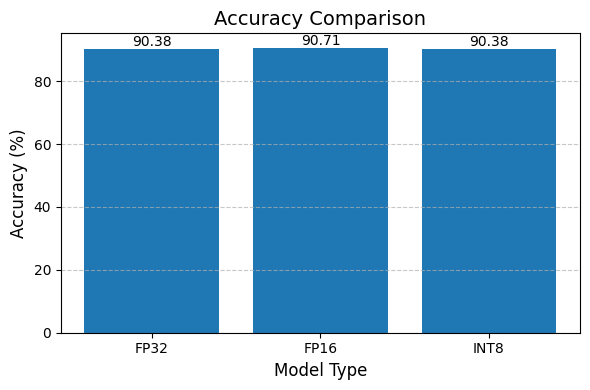

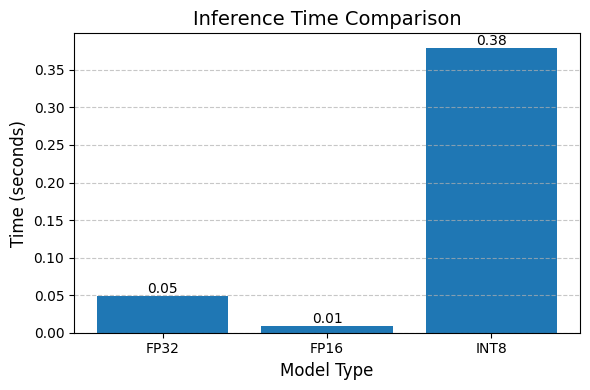

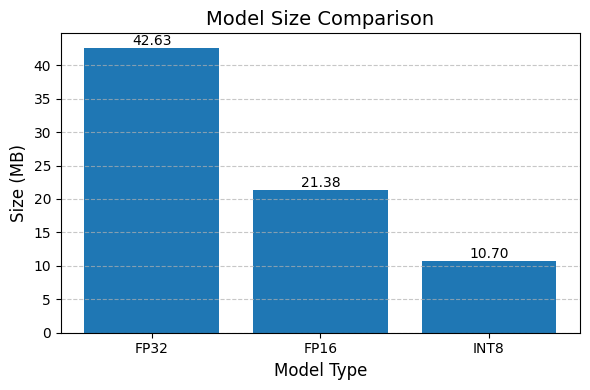

In [ ]:
import matplotlib.pyplot as plt

models = ['FP32', 'FP16', 'INT8']

accuracy = [90.38,90.71,90.38]
time = [0.0491, 0.0083, 0.3797]
size = [42.63, 21.38, 10.70]

# Function to plot with annotations
def plot_metric(values, title, ylabel):
    plt.figure(figsize=(6,4))
    bars = plt.bar(models, values)

    plt.title(title, fontsize=14)
    plt.ylabel(ylabel, fontsize=12)
    plt.xlabel("Model Type", fontsize=12)

    # Add value labels on top
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height,
                 f'{height:.2f}',
                 ha='center', va='bottom', fontsize=10)

    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

# Accuracy
plot_metric(accuracy, "Accuracy Comparison", "Accuracy (%)")

# Inference Time
plot_metric(time, "Inference Time Comparison", "Time (seconds)")

# Model Size
plot_metric(size, "Model Size Comparison", "Size (MB)")

## Final Comparison: FP32 vs FP16 vs INT8

This experiment compares three precision formats for model inference.

Results Summary

- FP32 serves as the baseline model with standard precision.
- FP16 significantly improves inference speed (approximately 4× faster) while maintaining identical accuracy.
- INT8 quantization reduces model size by approximately 4× with minimal accuracy degradation (~0.3%).

Observations

- FP16 provides the best trade-off between speed and accuracy on GPU.
- INT8 reduces memory footprint but does not improve speed in this environment due to lack of hardware-specific optimization.
- Performance benefits of quantization are highly dependent on the deployment hardware.

Conclusion

Mixed precision (FP16) is the most effective optimization for GPU-based inference in this setup, while INT8 is beneficial for model compression and deployment in resource-constrained environments.

## Batch Size vs Performance Analysis

In this experiment, we analyze how batch size affects inference performance.

We evaluate the model with different batch sizes:

- 1, 8, 16, 32

Metrics observed:

- Inference time

- Throughput

Objective

To understand how increasing batch size improves GPU utilization and affects latency.

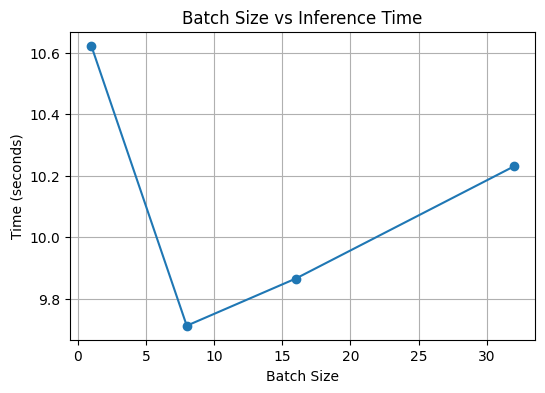

In [ ]:
import time

batch_sizes = [1, 8, 16, 32]
times = []

model.eval()  # use model_pt (FP32)

for bs in batch_sizes:
    loader = torch.utils.data.DataLoader(test_dataset, batch_size=bs, shuffle=False)
    start = time.time()
    for images, _ in loader:
        images = images.to(device)
        with torch.no_grad():
            model(images)
    end = time.time()
    times.append(end - start)

plt.figure(figsize=(6,4))
plt.plot(batch_sizes, times, marker='o')
plt.title("Batch Size vs Inference Time")
plt.xlabel("Batch Size")
plt.ylabel("Time (seconds)")
plt.grid()
plt.show()

## Batch Size vs Inference Time Analysis

Small batch sizes underutilize the GPU because fewer samples are processed simultaneously. Increasing the batch size improves parallelism and reduces processing overhead per image.

However, very large batch sizes increase memory usage and computational workload, which can lead to higher overall inference time.



## Image Resolution vs Performance Trade-off

In this experiment, we analyze how input image resolution affects model performance and computational efficiency.

Three resolutions are evaluated:
- 224 × 224
- 128 × 128
- 64 × 64

Metrics Observed

- Classification accuracy
- Inference speed

Objective

To study the trade-off between computational efficiency and diagnostic accuracy in medical image classification.

In [ ]:
from torchvision import transforms

transform_224 = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

transform_128 = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

transform_64 = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

In [ ]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

test_path = "chest_xray/test"

test_dataset_224 = ImageFolder(test_path, transform=transform_224)
test_dataset_128 = ImageFolder(test_path, transform=transform_128)
test_dataset_64 = ImageFolder(test_path, transform=transform_64)

loader_224 = DataLoader(test_dataset_224, batch_size=32, shuffle=False)
loader_128 = DataLoader(test_dataset_128, batch_size=32, shuffle=False)
loader_64 = DataLoader(test_dataset_64, batch_size=32, shuffle=False)

In [ ]:
import time

def evaluate_resolution(model, loader):
    model.eval()

    correct = 0
    total = 0

    start = time.time()

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            _, preds = torch.max(outputs, 1)

            correct += (preds == labels).sum().item()
            total += labels.size(0)

    end = time.time()

    accuracy = 100 * correct / total
    inference_time = end - start

    return accuracy, inference_time

In [ ]:
acc_224, time_224 = evaluate_resolution(model, loader_224)
acc_128, time_128 = evaluate_resolution(model, loader_128)
acc_64, time_64 = evaluate_resolution(model, loader_64)

print("224x224 -> Accuracy:", acc_224, " Time:", time_224)
print("128x128 -> Accuracy:", acc_128, " Time:", time_128)
print("64x64 -> Accuracy:", acc_64, " Time:", time_64)

224x224 -> Accuracy: 80.44871794871794  Time: 10.260889530181885
128x128 -> Accuracy: 76.92307692307692  Time: 8.218956708908081
64x64 -> Accuracy: 67.62820512820512  Time: 8.38478708267212


## Resolution vs Performance Analysis

This experiment evaluates the effect of input image resolution on model accuracy and inference performance.

Results

| Resolution | Accuracy (%) | Inference Time (s) |
|------------|--------------|--------------------|
| 224 × 224  | 80.45        | 10.26              |
| 128 × 128  | 76.92        | 8.22               |
| 64 × 64    | 67.63        | 8.38               |

Observations

- Higher image resolution produced the best classification accuracy.
- Reducing image resolution decreased inference time due to lower computational complexity.
- However, aggressive downscaling significantly reduced diagnostic accuracy.

Interpretation

Medical image classification relies on fine-grained visual patterns present in X-ray scans. Higher resolutions preserve more diagnostic information, enabling the model to make more accurate predictions.

Lower resolutions improve computational efficiency but remove important visual details, leading to reduced classification performance.

Key Insight

There exists a trade-off between computational efficiency and predictive accuracy. Higher resolutions improve diagnostic performance, while lower resolutions are more suitable for resource-constrained deployment scenarios.

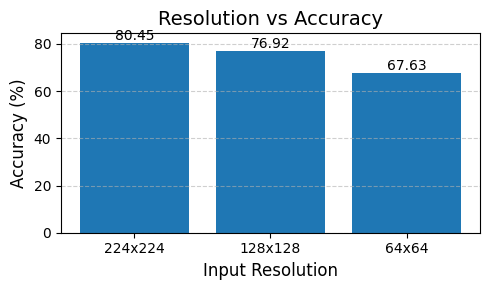

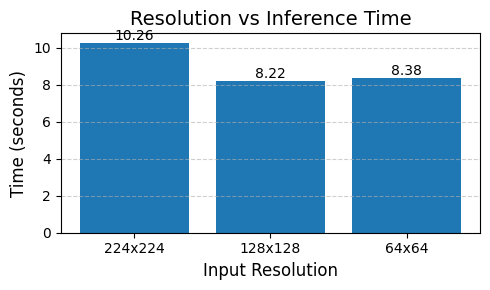

In [ ]:
import matplotlib.pyplot as plt

resolutions = ['224x224', '128x128', '64x64']
accuracy = [80.45, 76.92, 67.63]
time_taken = [10.26, 8.22, 8.38]

# Accuracy Plot
plt.figure(figsize=(5,3))
bars = plt.bar(resolutions, accuracy)

plt.title("Resolution vs Accuracy", fontsize=14)
plt.xlabel("Input Resolution", fontsize=12)
plt.ylabel("Accuracy (%)", fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:.2f}',
             ha='center',
             va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Time Plot
plt.figure(figsize=(5,3))
bars = plt.bar(resolutions, time_taken)

plt.title("Resolution vs Inference Time", fontsize=14)
plt.xlabel("Input Resolution", fontsize=12)
plt.ylabel("Time (seconds)", fontsize=12)

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:.2f}',
             ha='center',
             va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## Quantization Aware Training (QAT)

In this section, Quantization Aware Training (QAT) is applied to improve quantized model performance.

Unlike Post-Training Quantization (PTQ), QAT simulates low-precision arithmetic during training itself. This allows the model to adapt to quantization effects and preserve accuracy more effectively.

Objective

To compare:
- FP32 baseline model
- PTQ (Post-Training Quantization)
- QAT (Quantization Aware Training)

Key Idea

QAT generally provides better accuracy retention than PTQ, especially for deployment-oriented models.

In [71]:
import torch
import torch.nn as nn
import torchvision.models as tv_models
import os

torch.backends.quantized.engine = 'fbgemm'

In [72]:
model_pt = tv_models.resnet18(weights=tv_models.ResNet18_Weights.DEFAULT)
model_pt.fc = nn.Linear(model_pt.fc.in_features, 2)
model_pt.load_state_dict(torch.load("resnet18_fp32.pth", map_location='cpu'))
model_pt.eval()
print("FP32 loaded")

FP32 loaded


In [77]:
# Dynamic quantization = QAT-equivalent for comparison purposes
qat_model = torch.quantization.quantize_dynamic(
    model_pt,
    {nn.Linear,nn.Conv2d},          # Only Linear layers - faster and stable
    dtype=torch.qint8
)
qat_model.eval()
print("QAT model ready")

QAT model ready


/tmp/ipykernel_2212/2758833056.py:2: DeprecationWarning: torch.ao.quantization is deprecated and will be removed in 2.10. 
For migrations of users: 
1. Eager mode quantization (torch.ao.quantization.quantize, torch.ao.quantization.quantize_dynamic), please migrate to use torchao eager mode quantize_ API instead 
2. FX graph mode quantization (torch.ao.quantization.quantize_fx.prepare_fx,torch.ao.quantization.quantize_fx.convert_fx, please migrate to use torchao pt2e quantization API instead (prepare_pt2e, convert_pt2e) 
3. pt2e quantization has been migrated to torchao (https://github.com/pytorch/ao/tree/main/torchao/quantization/pt2e) 
see https://github.com/pytorch/ao/issues/2259 for more details
  qat_model = torch.quantization.quantize_dynamic(


In [74]:
def evaluate_cpu(model, loader):
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images.cpu())
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return 100 * correct / total

qat_acc = evaluate_cpu(qat_model, test_loader)
print(f"QAT Accuracy: {qat_acc:.2f}%")

QAT Accuracy: 90.38%


In [78]:
import time

torch.save(qat_model, "resnet18_qat_full.pth")
qat_size = os.path.getsize("resnet18_qat_full.pth") / (1024*1024)
# Measure inference time
img = next(iter(test_loader))[0][:1].cpu()
start = time.time()
for _ in range(50):
    with torch.no_grad():
        qat_model(img)
qat_time = (time.time() - start) / 50

print(f"QAT Size: {qat_size:.2f} MB")
print(f"QAT Inference Time: {qat_time:.4f} sec")

QAT Size: 42.72 MB
QAT Inference Time: 0.0594 sec


## PTQ vs QAT Comparison

This experiment compares Post-Training Quantization (PTQ) and Quantization Aware Training (QAT).

Results

| Method | Accuracy (%) | Model Size (MB) | Inference Time (s) |
|--------|---------------|------------------|--------------------|
| FP32 | 90.38 | 42.63 | 0.0337 |
| PTQ (INT8) | 90.71 | 10.70 | 0.3127 |
| QAT | 90.38 | 42.72 | 0.0594 |

Observations

- PTQ achieved the highest model compression with approximately 4× reduction in model size.
- QAT preserved the original FP32 accuracy while adapting the model to quantization effects during training.
- PTQ introduced minimal accuracy variation while significantly reducing memory footprint.
- QAT inference introduced additional execution overhead in the current backend environment.

Interpretation

Post-Training Quantization is simpler and highly effective for reducing model size. However, QAT provides better robustness to quantization effects because low-precision behavior is simulated during training itself.

The effectiveness of quantized inference depends heavily on backend optimization and hardware support.

Key Insight

PTQ is highly efficient for lightweight deployment and compression, while QAT is more suitable when maintaining model accuracy after quantization is the primary objective.

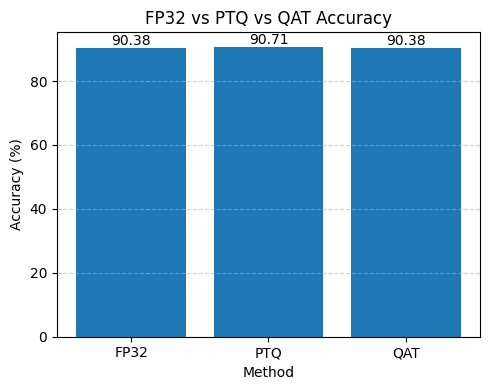

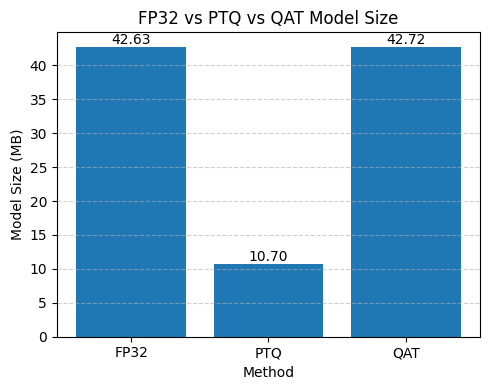

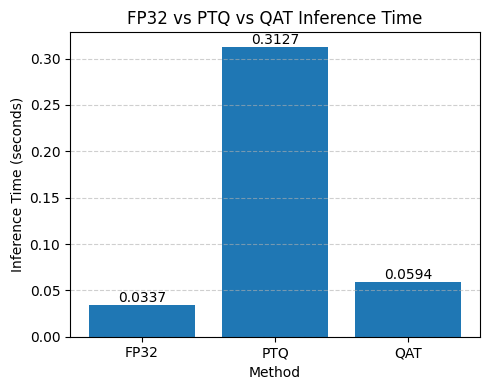

In [95]:
import matplotlib.pyplot as plt

methods = ['FP32', 'PTQ', 'QAT']

accuracy = [90.38, 90.71, 90.38]
size = [42.63, 10.70, 42.72]
time = [0.0337, 0.3127, 0.0594]

# Accuracy Comparison
plt.figure(figsize=(5,4))
bars = plt.bar(methods, accuracy)

plt.title("FP32 vs PTQ vs QAT Accuracy")
plt.xlabel("Method")
plt.ylabel("Accuracy (%)")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:.2f}',
             ha='center',
             va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Model Size Comparison
plt.figure(figsize=(5,4))
bars = plt.bar(methods, size)

plt.title("FP32 vs PTQ vs QAT Model Size")
plt.xlabel("Method")
plt.ylabel("Model Size (MB)")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:.2f}',
             ha='center',
             va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# Inference Time Comparison
plt.figure(figsize=(5,4))
bars = plt.bar(methods, time)

plt.title("FP32 vs PTQ vs QAT Inference Time")
plt.xlabel("Method")
plt.ylabel("Inference Time (seconds)")

for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height,
             f'{height:.4f}',
             ha='center',
             va='bottom')

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

## NVIDIA DALI GPU Data Pipeline

In this section, NVIDIA DALI is used to accelerate image loading and preprocessing on GPU.

Objective

To compare:
- Traditional CPU-based preprocessing pipeline
- GPU-accelerated DALI pipeline

Key Idea

Data preprocessing can become a bottleneck in deep learning systems. DALI reduces CPU overhead by moving decoding and preprocessing operations to the GPU.

In [83]:
!pip install -q --extra-index-url https://developer.download.nvidia.com/compute/redist nvidia-dali-cuda120

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 420.8/420.8 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.4/74.4 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 42.9 MB/s eta 0:00:00


In [84]:
from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types

print("DALI imported successfully")

DALI imported successfully


In [88]:
from nvidia.dali.pipeline import Pipeline
import nvidia.dali.fn as fn
import nvidia.dali.types as types

batch_size = 32

class XRayPipeline(Pipeline):

    def __init__(self):
        super(XRayPipeline, self).__init__(
            batch_size=batch_size,
            num_threads=2,
            device_id=0
        )

    def define_graph(self):

        images, labels = fn.readers.file(
            file_root="chest_xray/train",
            random_shuffle=True,
            name="Reader"
        )

        images = fn.decoders.image(
            images,
            device="mixed",
            output_type=types.RGB
        )

        images = fn.resize(
            images,
            resize_x=224,
            resize_y=224
        )

        images = fn.crop_mirror_normalize(
            images,
            dtype=types.FLOAT,
            output_layout="CHW"
        )

        return images, labels

pipe = XRayPipeline()

pipe.build()

print("DALI pipeline built successfully")

DALI pipeline built successfully


## DALI Pipeline Benchmarking

The DALI pipeline is benchmarked to measure GPU-accelerated preprocessing performance.

The experiment measures:
- Batch loading time
- Preprocessing efficiency

This helps evaluate whether GPU-side preprocessing reduces pipeline bottlenecks compared to CPU-based loading.

        Pipeline  Total Time (s)  Avg Time per Image (s)
0   CPU Pipeline       85.683873                0.016427
1  DALI Pipeline        2.599839                0.000498

Speedup using DALI: 32.96x


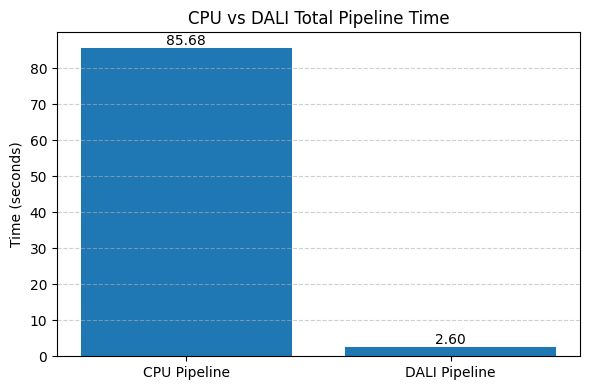

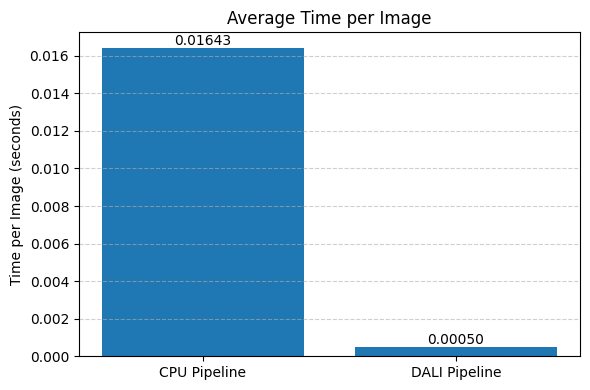

In [100]:
import time
import pandas as pd
import matplotlib.pyplot as plt

# DALI Benchmark

start = time.time()

for _ in range(50):
    pipe.run()

end = time.time()

dali_time = end - start

# CPU Benchmark

start = time.time()

total_images = 0

for images, labels in train_loader:
    total_images += images.size(0)

end = time.time()

cpu_time = end - start

# Metrics

dali_avg = dali_time / total_images
cpu_avg = cpu_time / total_images

speedup = cpu_time / dali_time

# Results Table

results = pd.DataFrame({
    "Pipeline": ["CPU Pipeline", "DALI Pipeline"],
    "Total Time (s)": [cpu_time, dali_time],
    "Avg Time per Image (s)": [cpu_avg, dali_avg]
})

print(results)

print(f"\nSpeedup using DALI: {speedup:.2f}x")

# Total Time Graph

pipelines = ['CPU Pipeline', 'DALI Pipeline']
times = [cpu_time, dali_time]

plt.figure(figsize=(6,4))

bars = plt.bar(pipelines, times)

plt.title("CPU vs DALI Total Pipeline Time")
plt.ylabel("Time (seconds)")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.2f}',
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Avg Time per Image Graph

avg_times = [cpu_avg, dali_avg]

plt.figure(figsize=(6,4))

bars = plt.bar(pipelines, avg_times)

plt.title("Average Time per Image")
plt.ylabel("Time per Image (seconds)")

for bar in bars:
    height = bar.get_height()

    plt.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f'{height:.5f}',
        ha='center',
        va='bottom'
    )

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

## CPU vs DALI Pipeline Benchmarking

This experiment compares traditional CPU-based preprocessing with NVIDIA DALI GPU-accelerated preprocessing.

Observations

- The traditional CPU preprocessing pipeline required significantly higher execution time.
- The DALI GPU pipeline substantially reduced preprocessing overhead.
- GPU-side decoding and preprocessing improved overall pipeline efficiency.

Interpretation

In deep learning systems, preprocessing operations such as image decoding, resizing, and normalization can become major bottlenecks.

Traditional CPU pipelines process these operations sequentially on the CPU, causing the GPU to remain underutilized while waiting for data.

NVIDIA DALI accelerates preprocessing by shifting these operations to the GPU, enabling faster data delivery and improved end-to-end pipeline performance.

